# 📈 Linear Regression — Under the Hood
> **Goal:** Understand *exactly* what `sklearn.linear_model.LinearRegression().fit()` does,  
> then extend to Ridge, Lasso, Grid Search, and diagnostics — **no sklearn, no black boxes.**

---


## 1 · Imports & Synthetic Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
np.random.seed(42)

# ── Synthetic dataset: house prices ───────────────────────────────────────────
n = 200
size      = np.random.uniform(500, 3500, n)          # sq ft
bedrooms  = np.random.randint(1, 6, n).astype(float)
age       = np.random.uniform(0, 50, n)              # years

# True relationship + noise
price = (120 * size) + (15_000 * bedrooms) - (500 * age) + 50_000
price += np.random.normal(0, 20_000, n)              # realistic noise

df = pd.DataFrame({'size': size, 'bedrooms': bedrooms, 'age': age, 'price': price})
print(df.head())
print(f"\nShape: {df.shape}")


          size  bedrooms        age          price
0  1623.620357       4.0  48.059528  257139.508436
1  3352.142919       3.0  45.267532  433838.740703
2  2695.981825       1.0   9.789557  378234.903993
3  2295.975453       4.0   3.468065  398133.866905
4   968.055921       4.0   5.038900  253694.401567

Shape: (200, 4)


## 2 · Train / Test Split (no sklearn)

In [3]:
def train_test_split_manual(df, test_size=0.2, seed=42):
    """Shuffle rows and slice into train / test."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(df))
    n_test = int(len(df) * test_size)
    test_idx  = idx[:n_test]
    train_idx = idx[n_test:]
    return df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)

train_df, test_df = train_test_split_manual(df)
print(f"Train: {len(train_df)} rows   |   Test: {len(test_df)} rows")


Train: 160 rows   |   Test: 40 rows


## 3 · Feature Matrix & Standardisation

Before solving for weights we **standardise** (zero mean, unit variance).  
This keeps gradient descent numerically stable and makes Ridge/Lasso penalties fair.


In [21]:
feature_cols = ['size', 'bedrooms', 'age']

# ── Compute mean & std on TRAIN only ──────────────────────────────────────────
mu  = train_df[feature_cols].mean()
sig = train_df[feature_cols].std()
def standardise(df_):
    return (df_[feature_cols] - mu) / sig

X_train = standardise(train_df).values          # shape (n_train, 3)
X_test  = standardise(test_df).values

y_train = train_df['price'].values
y_test  = test_df['price'].values

# ── Add intercept column (column of 1s) ───────────────────────────────────────
def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_intercept(X_train)              # shape (n_train, 4)
X_test_b  = add_intercept(X_test)         

print("X_train_b shape:", X_train_b.shape)      # (160, 4)  -- intercept + 3 features


X_train_b shape: (160, 4)


## 4 · Ordinary Least Squares — Closed-Form Solution

Linear regression minimises the **Sum of Squared Residuals (SSR)**:

$$\text{SSR} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \|y - X\beta\|^2$$

Taking the derivative, setting it to zero, and solving gives the **Normal Equation**:

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

This is **exactly** what `LinearRegression().fit()` computes internally (via SVD for stability).


In [5]:
def ols_fit(X_b, y):
    """Closed-form OLS: β = (XᵀX)⁻¹ Xᵀy"""
    # Use lstsq (SVD-based) — more stable than explicit matrix inverse
    beta, _, _, _ = np.linalg.lstsq(X_b, y, rcond=None)
    return beta

beta_ols = ols_fit(X_train_b, y_train)

print("Learned coefficients (β):")
labels = ['intercept'] + feature_cols
for name, val in zip(labels, beta_ols):
    print(f"  {name:12s}: {val:>12.2f}")


Learned coefficients (β):
  intercept   :    310502.09
  size        :    103896.55
  bedrooms    :     20798.24
  age         :     -9505.43


## 5 · Gradient Descent — The Iterative Way

Instead of solving analytically, we can **iteratively walk downhill** on the loss surface.

**Loss (MSE):**  
$$L(\beta) = \frac{1}{n}\|y - X\beta\|^2$$

**Gradient:**  
$$\nabla_\beta L = -\frac{2}{n} X^T(y - X\beta)$$

**Update rule:**  
$$\beta \leftarrow \beta - \alpha \cdot \nabla_\beta L$$

where $\alpha$ is the **learning rate**.


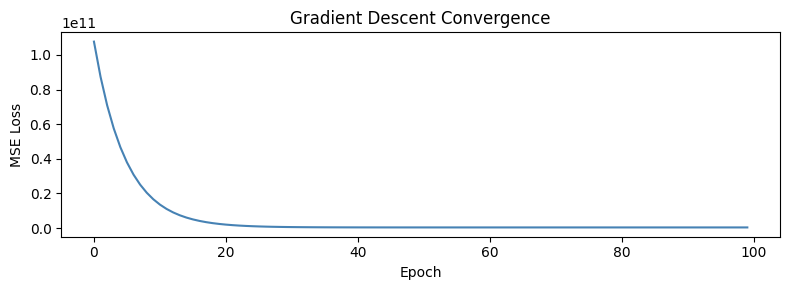


GD  coefficients: [310493.84 103891.1   20793.72  -9503.  ]
OLS coefficients: [310502.09 103896.55  20798.24  -9505.43]

✅ Both methods converge to the same answer!


In [23]:
def gradient_descent(X_b, y, lr=0.05, epochs=100):
    n, p = X_b.shape
    beta  = np.zeros(p)
    history = []

    for epoch in range(epochs):
        y_hat = X_b @ beta
        residuals = y - y_hat
        loss  = np.mean(residuals**2)                 # MSE
        grad  = -(2/n) * X_b.T @ residuals
        beta  = beta - lr * grad
        history.append(loss)

    return beta, history

beta_gd, loss_history = gradient_descent(X_train_b, y_train, lr=0.05, epochs=100)

# ── Plot convergence ───────────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(loss_history, color='steelblue', linewidth=1.5)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Gradient Descent Convergence")
plt.tight_layout(); plt.show()

print("\nGD  coefficients:", np.round(beta_gd, 2))
print("OLS coefficients:", np.round(beta_ols, 2))
print("\n✅ Both methods converge to the same answer!")


## 6 · Evaluation Metrics: R², RMSE, MAE

| Metric | Formula | Meaning |
|--------|---------|---------|
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained (1 = perfect) |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y-\hat{y})^2}$ | Error in same units as target |
| **MAE** | $\frac{1}{n}\sum|y-\hat{y}|$ | Average absolute error |

### Why sklearn returns *negative* MAE in cross-validation
`GridSearchCV` **maximises** its scoring metric.  
For error metrics (lower = better) sklearn negates them so higher still = better.  
`neg_mean_absolute_error = −MAE` → you negate it back to get the real MAE.


In [7]:
def predict(X_b, beta):
    return X_b @ beta

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - y_true.mean())**2)
    return 1 - ss_res / ss_tot

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# ── Evaluate on test set ───────────────────────────────────────────────────────
y_pred_ols = predict(X_test_b, beta_ols)
y_pred_gd  = predict(X_test_b, beta_gd)

print("=" * 42)
print(f"{'Metric':<12} {'OLS':>12} {'Grad. Desc.':>12}")
print("=" * 42)
print(f"{'R²':<12} {r2_score(y_test, y_pred_ols):>12.4f} {r2_score(y_test, y_pred_gd):>12.4f}")
print(f"{'RMSE':<12} {rmse(y_test, y_pred_ols):>12.2f} {rmse(y_test, y_pred_gd):>12.2f}")
print(f"{'MAE':<12} {mae(y_test, y_pred_ols):>12.2f} {mae(y_test, y_pred_gd):>12.2f}")
print(f"{'neg_MAE':<12} {-mae(y_test, y_pred_ols):>12.2f} {'← sklearn CV reports this':>12}")
print("=" * 42)


Metric                OLS  Grad. Desc.
R²                 0.9700       0.9700
RMSE             18462.90     18462.90
MAE              15378.49     15378.49
neg_MAE         -15378.49 ← sklearn CV reports this


## 7 · Diagnostic Plots

Good residuals should look like **white noise** — no pattern, centred at 0.


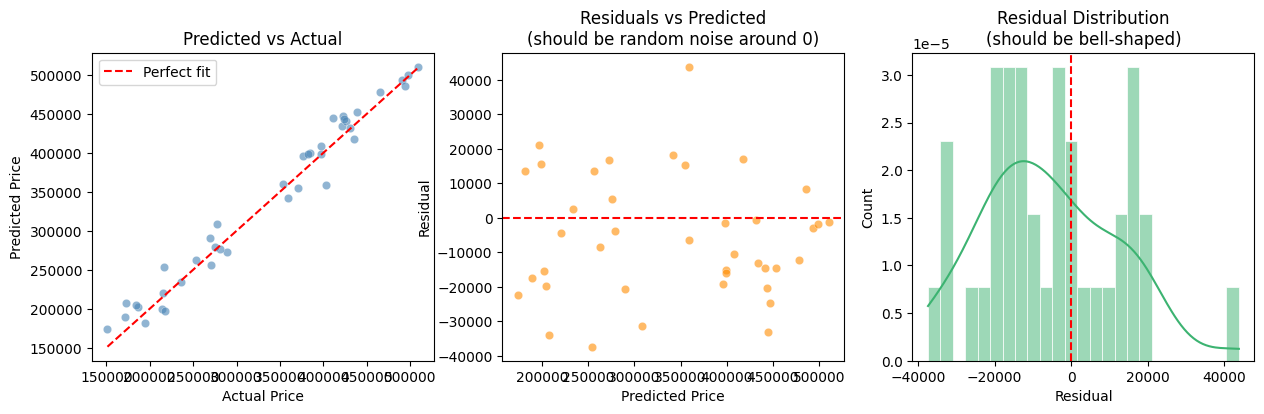

<Figure size 1500x400 with 0 Axes>

In [32]:
residuals = y_test - y_pred_ols

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Predicted vs Actual
axes[0].scatter(y_test, y_pred_ols, alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.3)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel("Actual Price"); axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Predicted vs Actual"); axes[0].legend()

# (b) Residuals vs Predicted
axes[1].scatter(y_pred_ols, residuals, alpha=0.6, color='darkorange', edgecolors='white', linewidths=0.3)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel("Predicted Price"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted\n(should be random noise around 0)")

# (c) Residual histogram
import seaborn as sns
plt.figure(figsize=(15, 4))
# Plot the histogram with a Kernel Density Estimate (KDE) curve
sns.histplot(
    residuals, 
    bins=25, 
    color='mediumseagreen', 
    edgecolor='white', 
    linewidth=0.5, 
    kde=True, 
    stat="density",  # Scales the y-axis to a density
    ax=axes[2]       # Targets your specific subplot axis
)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel("Residual"); axes[2].set_ylabel("Count")
axes[2].set_title("Residual Distribution\n(should be bell-shaped)")

plt.tight_layout(); plt.show()



## 8 · Variance Inflation Factor (VIF)

**Multicollinearity** means your features are correlated with each other.  
This inflates coefficient standard errors and makes them unstable.

**VIF** measures how much the variance of a coefficient is inflated due to correlation:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ is the R² from regressing feature $j$ on **all other features**.

| VIF | Interpretation |
|-----|---------------|
| 1 | No correlation |
| 1–5 | Moderate (usually acceptable) |
| > 5 | High — investigate |
| > 10 | Severe multicollinearity |


In [9]:
def compute_vif(X):
    """X is a 2D array of features (NO intercept column)."""
    n_features = X.shape[1]
    vif_values = []

    for j in range(n_features):
        # Regress feature j on all others
        X_others = np.delete(X, j, axis=1)
        X_others_b = add_intercept(X_others)
        beta_j = ols_fit(X_others_b, X[:, j])
        y_hat_j = X_others_b @ beta_j
        r2_j = r2_score(X[:, j], y_hat_j)
        r2_j = min(r2_j, 0.9999)                  # avoid division by zero
        vif_values.append(1 / (1 - r2_j))

    return vif_values

vif_vals = compute_vif(X_train)

print("Variance Inflation Factors")
print("-" * 30)
for feat, v in zip(feature_cols, vif_vals):
    flag = "⚠️ HIGH" if v > 5 else "✅ OK"
    print(f"  {feat:12s}: VIF = {v:.2f}  {flag}")

print("\n💡 VIFs close to 1 — our synthetic features are independent (as expected).")


Variance Inflation Factors
------------------------------
  size        : VIF = 1.01  ✅ OK
  bedrooms    : VIF = 1.01  ✅ OK
  age         : VIF = 1.00  ✅ OK

💡 VIFs close to 1 — our synthetic features are independent (as expected).


## 9 · Ridge Regression (L2 Regularisation)

**Problem OLS has:** When features are correlated (or we have many features), OLS coefficients blow up.

**Ridge fix:** Add an L2 penalty on the magnitude of coefficients:

$$L_{ridge}(\beta) = \underbrace{\|y - X\beta\|^2}_{\text{fit the data}} + \underbrace{\lambda \|\beta_{1:}\|^2}_{\text{keep β small}}$$

The closed-form solution becomes:

$$\hat{\beta}_{ridge} = (X^T X + \lambda I)^{-1} X^T y$$

- $\lambda = 0$ → same as OLS  
- $\lambda \to \infty$ → all coefficients → 0  
- Ridge **shrinks** coefficients but never makes them exactly zero


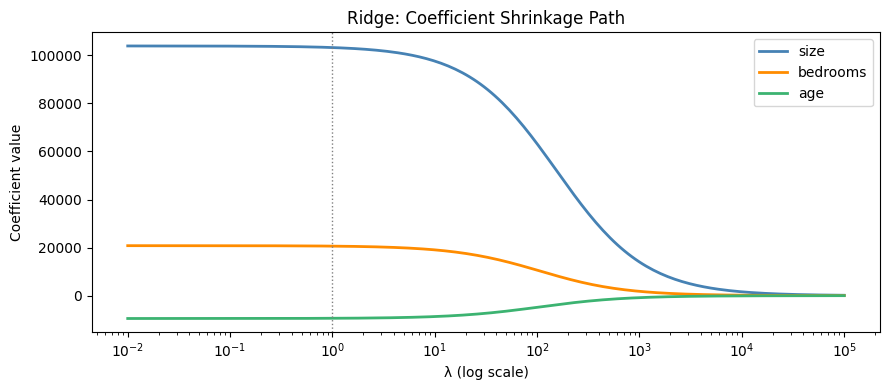

As λ → ∞ all coefficients → 0 (shrink, but never exactly zero).


In [37]:
def ridge_fit(X_b, y, lam):
    """Ridge: β = (XᵀX + λI)⁻¹ Xᵀy  (skip intercept from penalty via slicing)"""
    n, p = X_b.shape
    I = np.eye(p)
    I[0, 0] = 0                          # do NOT penalise the intercept
    beta = np.linalg.solve(X_b.T @ X_b + lam * I, X_b.T @ y)
    return beta

# ── Show how coefficients shrink as lambda grows ───────────────────────────────
lambdas = np.logspace(-2, 5, 200)
coef_paths = []
for lam in lambdas:
    b = ridge_fit(X_train_b, y_train, lam)
    coef_paths.append(b[1:])             # drop intercept

coef_paths = np.array(coef_paths)

plt.figure(figsize=(9, 4))
colors = ['steelblue', 'darkorange', 'mediumseagreen']
for i, (feat, col) in enumerate(zip(feature_cols, colors)):
    plt.semilogx(lambdas, coef_paths[:, i], label=feat, color=col, linewidth=2)

plt.axvline(1, color='gray', linestyle=':', linewidth=1)
plt.xlabel("λ (log scale)"); plt.ylabel("Coefficient value")
plt.title("Ridge: Coefficient Shrinkage Path")
plt.legend(); plt.tight_layout(); plt.show()

print("As λ → ∞ all coefficients → 0 (shrink, but never exactly zero).")


## 10 · Lasso Regression (L1 Regularisation)

Lasso uses an L1 penalty:

$$L_{lasso}(\beta) = \|y - X\beta\|^2 + \lambda \|\beta_{1:}\|_1$$

No closed form → solved with **coordinate descent** (update one β at a time).  
The key insight is the **soft-threshold operator**:

$$\hat{\beta}_j = \text{sign}(z_j) \cdot \max(|z_j| - \lambda, 0)$$

This **zeroes out** small coefficients → built-in **feature selection**!

| | Ridge | Lasso |
|--|--|--|
| Penalty | $\lambda\|\beta\|^2$ | $\lambda\|\beta\|_1$ |
| Exact zeros? | ❌ No | ✅ Yes |
| Use when | All features matter | Many irrelevant features |


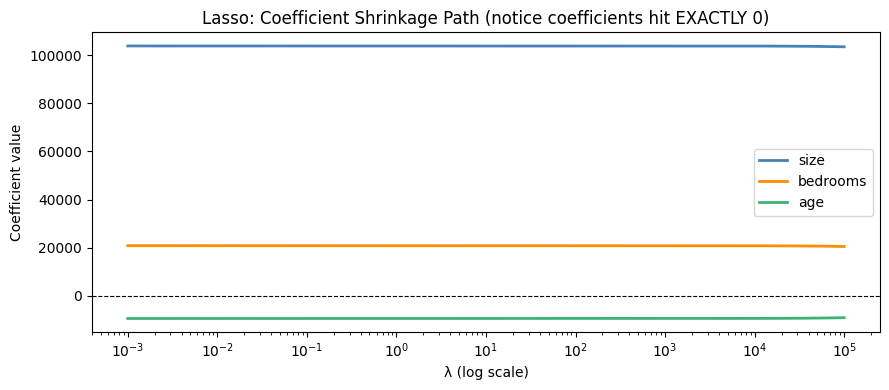

In [11]:
def soft_threshold(z, threshold):
    """The magic that makes Lasso produce exact zeros."""
    return np.sign(z) * np.maximum(np.abs(z) - threshold, 0)

def lasso_fit(X_b, y, lam, max_iter=1000, tol=1e-6):
    """Coordinate descent for Lasso."""
    n, p = X_b.shape
    beta = np.zeros(p)

    for _ in range(max_iter):
        beta_old = beta.copy()
        for j in range(p):
            # Partial residual: y minus contribution of all OTHER features
            r_j = y - X_b @ beta + X_b[:, j] * beta[j]
            z_j = X_b[:, j] @ r_j / n

            if j == 0:                         # intercept — no penalty
                beta[j] = z_j / (X_b[:, j] @ X_b[:, j] / n)
            else:
                beta[j] = soft_threshold(z_j, lam / (2*n)) / (X_b[:, j] @ X_b[:, j] / n)

        if np.max(np.abs(beta - beta_old)) < tol:
            break
    return beta

# ── Coefficient paths ──────────────────────────────────────────────────────────
lambdas_lasso = np.logspace(-3, 5, 150)
coef_paths_lasso = []
for lam in lambdas_lasso:
    b = lasso_fit(X_train_b, y_train, lam)
    coef_paths_lasso.append(b[1:])

coef_paths_lasso = np.array(coef_paths_lasso)

plt.figure(figsize=(9, 4))
for i, (feat, col) in enumerate(zip(feature_cols, colors)):
    plt.semilogx(lambdas_lasso, coef_paths_lasso[:, i], label=feat, color=col, linewidth=2)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel("λ (log scale)"); plt.ylabel("Coefficient value")
plt.title("Lasso: Coefficient Shrinkage Path (notice coefficients hit EXACTLY 0)")
plt.legend(); plt.tight_layout(); plt.show()


## 11 · Grid Search with K-Fold Cross-Validation

**Problem:** How do we pick the best $\lambda$?

**K-Fold CV idea:**  
1. Split training data into K equal folds  
2. For each $\lambda$: train on K-1 folds, evaluate on the held-out fold  
3. Average the K scores → honest estimate of generalisation error  
4. Pick the $\lambda$ with the best average score


Best λ : 1.7957
Best CV R² : 0.9573


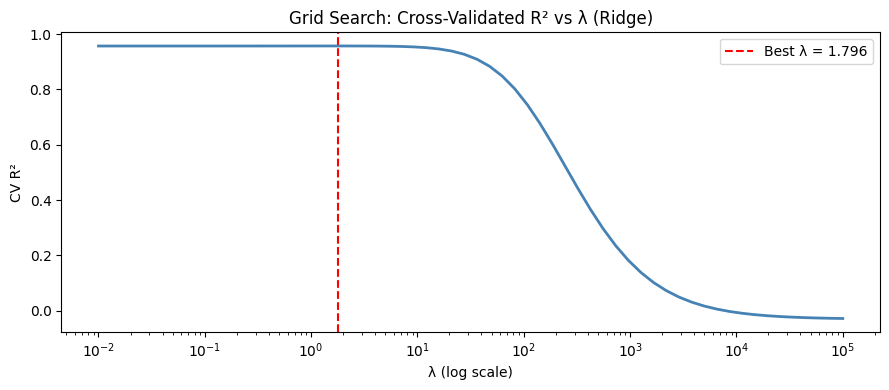

In [12]:
def kfold_indices(n, k=5, seed=42):
    """Yield (train_idx, val_idx) tuples for k folds."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    folds = np.array_split(idx, k)
    for i in range(k):
        val_idx   = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        yield train_idx, val_idx

def cross_val_score_ridge(X_b, y, lam, k=5):
    """Return mean R² across k folds for a given lambda."""
    scores = []
    for tr, val in kfold_indices(len(y), k):
        b = ridge_fit(X_b[tr], y[tr], lam)
        scores.append(r2_score(y[val], X_b[val] @ b))
    return np.mean(scores)

# ── Grid search over lambda ────────────────────────────────────────────────────
param_grid = np.logspace(-2, 5, 60)
cv_scores  = [cross_val_score_ridge(X_train_b, y_train, lam) for lam in param_grid]

best_lam   = param_grid[np.argmax(cv_scores)]
best_score = max(cv_scores)

print(f"Best λ : {best_lam:.4f}")
print(f"Best CV R² : {best_score:.4f}")

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.semilogx(param_grid, cv_scores, color='steelblue', linewidth=2)
plt.axvline(best_lam, color='red', linestyle='--', label=f'Best λ = {best_lam:.3f}')
plt.xlabel("λ (log scale)"); plt.ylabel("CV R²")
plt.title("Grid Search: Cross-Validated R² vs λ (Ridge)")
plt.legend(); plt.tight_layout(); plt.show()


## 12 · Final Model Comparison

In [13]:
# Train final Ridge with best lambda
beta_ridge = ridge_fit(X_train_b, y_train, best_lam)
y_pred_ridge = predict(X_test_b, beta_ridge)

# A Lasso with a reasonable lambda
beta_lasso = lasso_fit(X_train_b, y_train, lam=500)
y_pred_lasso = predict(X_test_b, beta_lasso)

print("=" * 55)
print(f"{'Model':<18} {'R²':>8} {'RMSE':>12} {'MAE':>12}")
print("=" * 55)
for name, y_pred in [("OLS", y_pred_ols), ("Ridge (best λ)", y_pred_ridge), ("Lasso", y_pred_lasso)]:
    print(f"{name:<18} {r2_score(y_test, y_pred):>8.4f} {rmse(y_test, y_pred):>12.2f} {mae(y_test, y_pred):>12.2f}")
print("=" * 55)

# ── Coefficient comparison ─────────────────────────────────────────────────────
print("\nCoefficient comparison (standardised features):")
print(f"{'Feature':<12} {'OLS':>12} {'Ridge':>12} {'Lasso':>12}")
print("-" * 50)
for i, feat in enumerate(feature_cols):
    print(f"{feat:<12} {beta_ols[i+1]:>12.1f} {beta_ridge[i+1]:>12.1f} {beta_lasso[i+1]:>12.1f}")
print("\n💡 Ridge shrinks — Lasso may zero some out completely.")


Model                    R²         RMSE          MAE
OLS                  0.9700     18462.90     15378.49
Ridge (best λ)       0.9704     18360.99     15078.34
Lasso                0.9700     18462.60     15377.35

Coefficient comparison (standardised features):
Feature               OLS        Ridge        Lasso
--------------------------------------------------
size             103896.6     102704.0     103894.8
bedrooms          20798.2      20463.3      20796.5
age               -9505.4      -9351.2      -9503.7

💡 Ridge shrinks — Lasso may zero some out completely.


## 13 · Conceptual Summary — The Full Picture

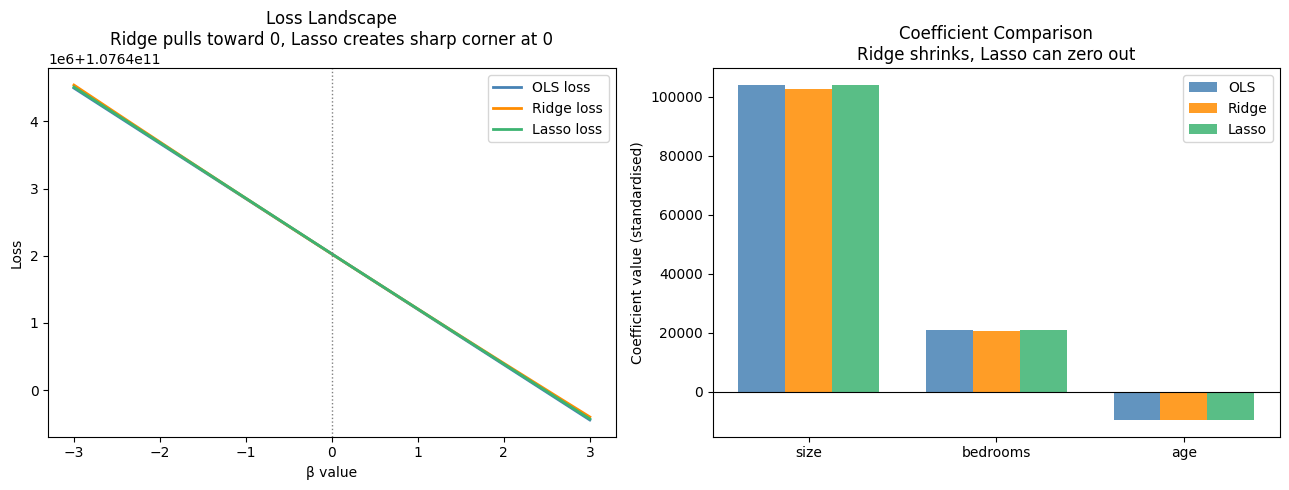

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Left: loss landscape intuition (1D slice) ---------------------------------
beta_range = np.linspace(-3, 3, 300)
ols_loss   = [np.mean((y_train - (X_train_b[:, 0]*b + X_train_b[:, 1]*b))**2) for b in beta_range]
ridge_loss = [l + 5000 * b**2 for l, b in zip(ols_loss, beta_range)]
lasso_loss = [l + 5000 * abs(b) for l, b in zip(ols_loss, beta_range)]

axes[0].plot(beta_range, ols_loss,   label='OLS loss',   color='steelblue',     linewidth=2)
axes[0].plot(beta_range, ridge_loss, label='Ridge loss',  color='darkorange',    linewidth=2)
axes[0].plot(beta_range, lasso_loss, label='Lasso loss',  color='mediumseagreen',linewidth=2)
axes[0].axvline(0, color='gray', linestyle=':', linewidth=1)
axes[0].set_xlabel("β value"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Landscape\nRidge pulls toward 0, Lasso creates sharp corner at 0")
axes[0].legend()

# -- Right: shrinkage comparison bar chart ------------------------------------
x = np.arange(len(feature_cols))
w = 0.25
axes[1].bar(x - w, beta_ols[1:],   width=w, label='OLS',   color='steelblue',      alpha=0.85)
axes[1].bar(x,     beta_ridge[1:], width=w, label='Ridge', color='darkorange',     alpha=0.85)
axes[1].bar(x + w, beta_lasso[1:], width=w, label='Lasso', color='mediumseagreen', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(feature_cols)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel("Coefficient value (standardised)")
axes[1].set_title("Coefficient Comparison\nRidge shrinks, Lasso can zero out")
axes[1].legend()

plt.tight_layout(); plt.show()


## 14 · Cheat Sheet

```
OLS          → minimise ||y - Xβ||²          β = (XᵀX)⁻¹Xᵀy
Ridge (L2)   → + λ||β||²                     β = (XᵀX + λI)⁻¹Xᵀy   (shrinks, no zeros)
Lasso (L1)   → + λ||β||₁                     coordinate descent       (shrinks + zeroes)

R²   = 1 - SS_res/SS_tot    → proportion of variance explained
RMSE = √mean((y-ŷ)²)        → error in same units as y
MAE  = mean(|y-ŷ|)          → robust to outliers
neg_MAE                      → sklearn negates errors so "higher = better" in CV

VIF  = 1/(1-R²_j)           → >5: worry, >10: serious multicollinearity

Grid Search + K-Fold CV      → find best λ without overfitting to test set
```

**Rule of thumb for choosing regularisation:**
- Many features, expect most are noise → **Lasso** (automatic feature selection)  
- All features probably matter, just noisy → **Ridge**  
- Uncertain → try both, use CV to decide
